# 🎨 CHALLENGE: 3채널 컬러 CNN 확장
## CIFAR-10처럼 컬러(RGB) 이미지로 동일 구조 적용

**01 노트북과의 차이점:**
- 흑백(1채널) → **컬러(3채널)**
- `reshape(-1, 64, 64, 1)` → `reshape(-1, 64, 64, 3)`
- Conv2D 첫 레이어 input_shape: `(64, 64, 1)` → `(64, 64, 3)`
- 파라미터 수 변화 분석

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.callbacks import ModelCheckpoint, EarlyStopping

import os
os.chdir(r"C:\Users\금정산2-PC12\find_bori\my-cat-classifier")

IMG_SIZE = 64
DATA_DIR = Path("data")

---
## 1. 컬러 이미지 로드 (3채널)

In [2]:
def load_images_color(folder, label):
    """컬러(RGB) 이미지로 로드 — 3채널"""
    images = []
    valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    for img_path in sorted(folder.iterdir()):
        if img_path.suffix.lower() not in valid_ext:
            continue
        try:
            img = Image.open(img_path).convert("RGB")  # ★ 컬러 3채널
            img = img.resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img))
        except Exception:
            pass
    return np.array(images), np.full(len(images), label)


# 데이터 로드
my_train, my_train_y = load_images_color(DATA_DIR / "train" / "my_cat", 1)
other_train, other_train_y = load_images_color(DATA_DIR / "train" / "other_cats", 0)
my_val, my_val_y = load_images_color(DATA_DIR / "val" / "my_cat", 1)
other_val, other_val_y = load_images_color(DATA_DIR / "val" / "other_cats", 0)

train_images = np.concatenate([my_train, other_train]).astype("float32") / 255.0
train_labels = np.concatenate([my_train_y, other_train_y])
val_images = np.concatenate([my_val, other_val]).astype("float32") / 255.0
val_labels = np.concatenate([my_val_y, other_val_y])

# ★ 컬러라서 이미 (N, 64, 64, 3) — reshape 명시적으로 확인
train_images = train_images.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
val_images = val_images.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

print(f"학습 shape: {train_images.shape}")   # (N, 64, 64, 3)
print(f"검증 shape: {val_images.shape}")
print(f"→ 3채널 컬러! CIFAR-10(32×32×3)과 동일한 구조")

학습 shape: (305, 64, 64, 3)
검증 shape: (78, 64, 64, 3)
→ 3채널 컬러! CIFAR-10(32×32×3)과 동일한 구조


C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\990763862.py:17: UserWarning: Glyph 52972 (\N{HANGUL SYLLABLE KEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\990763862.py:17: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\990763862.py:17: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\990763862.py:17: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\990763862.py:17: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\990763862.py:17: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) mis

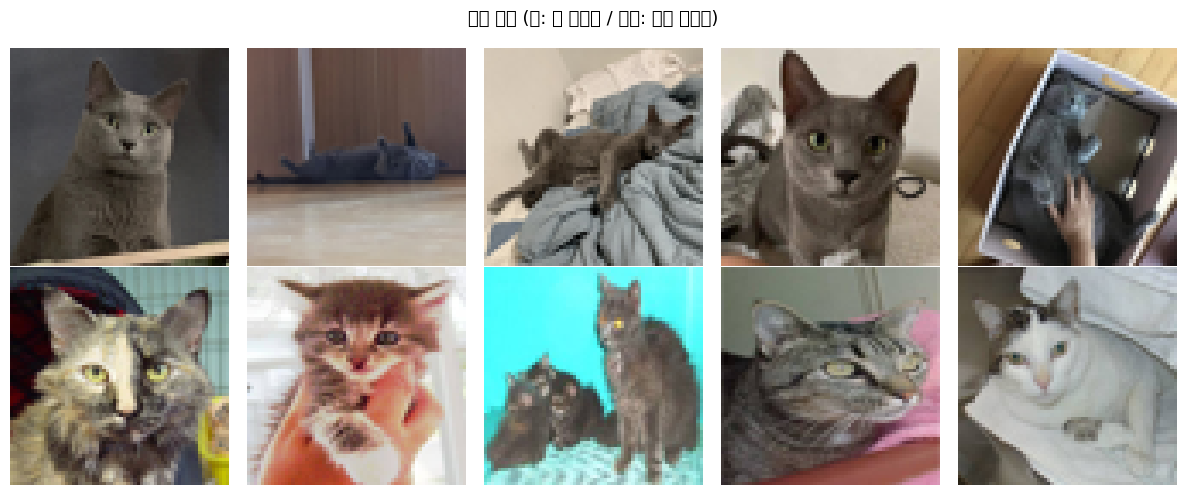

In [3]:
# 컬러 샘플 확인
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("컬러 샘플 (위: 내 고양이 / 아래: 다른 고양이)", fontsize=13)

for i, ax in enumerate(axes[0]):
    idx = np.where(train_labels == 1)[0]
    if i < len(idx):
        ax.imshow(train_images[idx[i]])
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    idx = np.where(train_labels == 0)[0]
    if i < len(idx):
        ax.imshow(train_images[idx[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## 2. 컬러 CNN 모델 (동일 구조, input_channels=3)

In [4]:
color_model = keras.Sequential([
    # 첫 번째 Conv→Pool
    layers.Conv2D(32, kernel_size=3, activation="relu",
                  padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),  # ★ 3채널
    layers.MaxPooling2D(pool_size=2),

    # 두 번째 Conv→Pool
    layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=2),

    # 분류기
    layers.Flatten(),
    layers.Dense(100, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
])

color_model.summary()

c:\Users\금정산2-PC12\find_bori\my-cat-classifier\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,638,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,657,993 (6.32 MB)

 Trainable params: 1,657,993 (6.32 MB)

 Non-trainable params: 0 (0.00 B)

### 1채널 vs 3채널 파라미터 수 비교

**첫 번째 Conv2D(32, 3)의 파라미터:**
- 흑백 (1채널): (3×3×**1**+1) × 32 = **320**
- 컬러 (3채널): (3×3×**3**+1) × 32 = **896**

→ 입력 채널이 3배 늘어나면 첫 번째 Conv의 가중치도 3배!
→ 나머지 레이어는 동일 (두 번째 Conv부터는 입력 채널이 이전 필터 수로 결정)

In [5]:
# 흑백 모델과 파라미터 비교
gray_model = keras.Sequential([
    layers.Conv2D(32, 3, activation="relu", padding="same",
                  input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(100, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
])

print("=" * 55)
print(f"{'레이어':<22} {'흑백(1ch)':<15} {'컬러(3ch)':<15}")
print("=" * 55)
for lg, lc in zip(gray_model.layers, color_model.layers):
    print(f"{lg.name:<22} {lg.count_params():<15,} {lc.count_params():<15,}")
print("-" * 55)
print(f"{'총합':<22} {gray_model.count_params():<15,} {color_model.count_params():<15,}")
print(f"{'차이':<22} {color_model.count_params() - gray_model.count_params():>+14,}")

레이어                    흑백(1ch)         컬러(3ch)        
conv2d_2               320             896            
max_pooling2d_2        0               0              
conv2d_3               18,496          18,496         
max_pooling2d_3        0               0              
flatten_1              0               0              
dense_2                1,638,500       1,638,500      
dropout_1              0               0              
dense_3                101             101            
-------------------------------------------------------
총합                     1,657,417       1,657,993      
차이                               +576


---
## 3. 학습

In [6]:
color_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
    jit_compile=False,
)

Path("models").mkdir(exist_ok=True)

callbacks = [
    ModelCheckpoint(
        filepath="models/best_cat_color.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = color_model.fit(
    train_images, train_labels,
    epochs=30,
    batch_size=16,
    validation_data=(val_images, val_labels),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8209 - loss: 0.5024
Epoch 1: val_accuracy improved from None to 0.87179, saving model to models/best_cat_color.keras

Epoch 1: finished saving model to models/best_cat_color.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8689 - loss: 0.4088 - val_accuracy: 0.8718 - val_loss: 0.3635
Epoch 2/30
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8788 - loss: 0.3576
Epoch 2: val_accuracy did not improve from 0.87179
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8787 - loss: 0.3428 - val_accuracy: 0.8718 - val_loss: 0.5030
Epoch 3/30
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8779 - loss: 0.3637
Epoch 3: val_accuracy did not improve from 0.87179
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8787 - loss: 0.3390 - val_accuracy: 0.8718 - val_loss: 0.3378
Epoch 4/30
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8805 - loss: 0.2841
Epoch 4: val_accuracy did not improve from 0.87179

---
## 4. 결과

C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\1400185590.py:17: UserWarning: Glyph 52972 (\N{HANGUL SYLLABLE KEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\1400185590.py:17: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\1400185590.py:17: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\1400185590.py:17: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\1400185590.py:17: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\금정산2-PC12\AppData\Local\Temp\ipykernel_904\1400185590.py:17: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JE

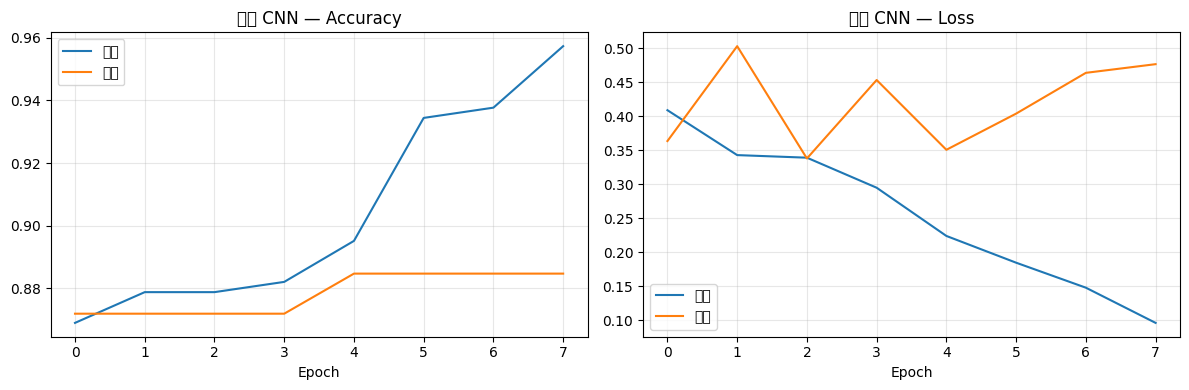


🏆 컬러 CNN 최고 검증 정확도: 0.8846 (88.46%)


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="학습")
ax1.plot(history.history["val_accuracy"], label="검증")
ax1.set_title("컬러 CNN — Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["loss"], label="학습")
ax2.plot(history.history["val_loss"], label="검증")
ax2.set_title("컬러 CNN — Loss")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val = max(history.history["val_accuracy"])
print(f"\n🏆 컬러 CNN 최고 검증 정확도: {best_val:.4f} ({best_val:.2%})")

---
## 5. 흑백 vs 컬러 성능 분석

### 예상되는 차이점

| 항목 | 흑백 (1ch) | 컬러 (3ch) |
|------|-----------|-----------|
| 입력 정보 | 밝기만 | 밝기 + 색상 |
| 첫 Conv 파라미터 | 320 | 896 |
| 총 파라미터 | 적음 | 약간 많음 |
| 학습 속도 | 빠름 | 약간 느림 |

### 분석 포인트
- 고양이 털 **색상/무늬**가 구분에 중요하다면 → 컬러가 유리
- 고양이 **체형/얼굴형**이 구분에 중요하다면 → 흑백으로도 충분
- 데이터가 적을 때는 파라미터가 적은 흑백이 과적합에 강할 수 있음
- CIFAR-10은 색상이 중요한 클래스(자동차 색, 하늘색 등)가 있어 3채널이 필수

In [8]:
# 컬러 이미지 예측 함수
def predict_cat_color(image_path: str, model):
    """컬러 이미지로 예측"""
    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img).astype("float32") / 255.0
    img_array = img_array.reshape(1, IMG_SIZE, IMG_SIZE, 3)  # 4D, 3채널

    prob = model.predict(img_array, verbose=0)[0][0]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")

    if prob > 0.5:
        plt.title(f"🐱 내 고양이! ({prob:.1%})", fontsize=14)
    else:
        plt.title(f"😿 다른 고양이 ({1-prob:.1%})", fontsize=14)
    plt.show()


# 사용 예시:
# predict_cat_color("test_images/test1.jpg", color_model)